# Fraud Detection – Post-Preprocessing Light EDA

This notebook performs a lightweight exploratory data analysis (EDA) on the **processed** dataset to verify the quality of the data before modeling.

The goal is to:
1.  Verify that preprocessing (imputation, scaling, encoding) was successful.
2.  Check the final distribution of the target variable.
3.  Visualize the distributions and correlations of key features after transformations.
4.  Identify any remaining anomalies or outliers.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


## 1. Load Processed Data

We load the training features and labels that were saved during the preprocessing stage.


In [2]:
X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet").squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


X_train shape: (472432, 422)
y_train shape: (472432,)


## 2. Missing Values Verification

One of the primary goals of preprocessing was to handle missing values. Here, we verify that no missing values remain in the dataset.


In [3]:
missing_counts = X_train.isnull().sum()
total_missing = missing_counts.sum()

print(f"Total missing values in X_train: {total_missing}")

if total_missing == 0:
    print("✅ Success: No missing values detected.")
else:
    print("❌ Warning: Missing values still present!")
    print("\nTop features with missing values:")
    print(missing_counts[missing_counts > 0].sort_values(ascending=False).head(10))


Total missing values in X_train: 0
✅ Success: No missing values detected.


## 3. Target Distribution

We examine the distribution of the target variable `isFraud` to confirm the class imbalance in the training set.


Target Distribution:
          Count  Percentage (%)
isFraud                        
0        455902       96.501084
1         16530        3.498916


C:\Users\Mohsen\AppData\Local\Temp\ipykernel_5080\1744066346.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


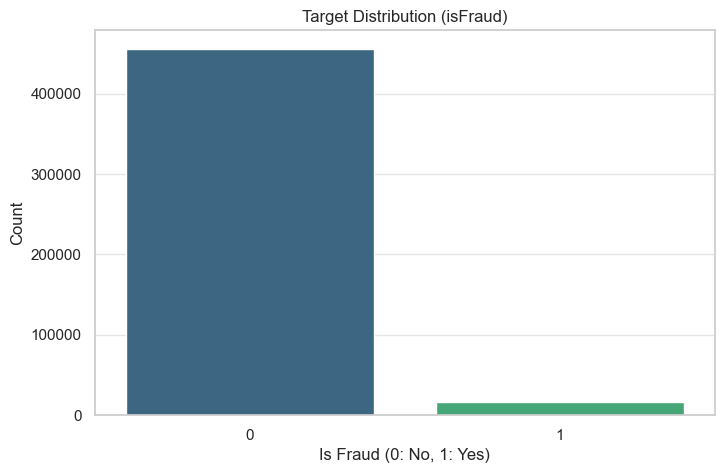

In [4]:
counts = y_train.value_counts()
percent = y_train.value_counts(normalize=True) * 100

print("Target Distribution:")
print(pd.DataFrame({'Count': counts, 'Percentage (%)': percent}))

plt.figure(figsize=(8, 5))
sns.countplot(x=y_train, palette='viridis')
plt.title("Target Distribution (isFraud)")
plt.xlabel("Is Fraud (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()


**Observation:**
The dataset remains highly imbalanced, which is expected. This confirms that stratified splitting was used during preprocessing to maintain this distribution.


## 4. Feature Distributions (Post-Scaling)

We take a sample of the data and visualize the distributions of the first 10 numerical features. Since scaling was applied, we expect most features to be centered around 0.


In [ ]:
# Sampling for faster visualization
X_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42)
y_sample = y_train.loc[X_sample.index]

# Select first 10 numerical columns
num_cols = X_sample.select_dtypes(include=np.number).columns[:10]

X_sample[num_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle("Distributions of Key Features After Preprocessing", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Observation:**
Most features are now scaled and centered. Features like `TransactionAmt_log` should show a more normal distribution compared to their raw counterparts.


## 5. Correlation Analysis

We check for correlations between the first 10 numerical features to ensure no redundant information or unexpected relationships were introduced.


In [ ]:
plt.figure(figsize=(12, 10))
corr_matrix = X_sample[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Sample of 10 Features)")
plt.show()


## 6. Outlier Inspection

We use boxplots to inspect the range and outliers of the scaled features.


In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=X_sample[num_cols])
plt.xticks(rotation=45)
plt.title("Outlier Detection (Scaled Features)")
plt.show()


**Observation:**
Standard scaling preserves outliers. The boxplots show that several features still have values far from the mean, which is typical for fraud detection datasets where fraudulent behavior often appears as an anomaly.


## 7. Summary of Post-Processing State

The processed data is now in a clean state:
- **Missing Values**: None (verified).
- **Encoding**: Categorical variables have been converted to numeric.
- **Scaling**: Numerical features are standardized.
- **Feature Engineering**: New features like `TransactionAmt_log` and `TransactionAmt_decimal` are present.
- **Target**: Imbalance is acknowledged and will be handled during modeling.

The dataset is ready for **Feature Reduction** or **Modeling**.
